---
# Le nettoyage des données aberrantes
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/Illustration-of-outliers-in-a-2-D-data_W640.jpg"  width="500" />
    <div>
    <font size="1.5">Image Source: https://www.researchgate.net/publication/353199864_KAGO_an_approximate_adaptive_grid-based_outlier_detection_approach_using_kernel_density_estimate/figures?lo=1/</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous verrons quelques méthodes de détection et d'élimination des valeurs aberrantes. 

## Table des matières

1. Génération des données
2. Élimination des données aberrantes
    1. Covariance robuste
    2. SVM monoclasse
    3. Forêt d'isolation
    4. Facteur d'aberration local
2. Conclusion

#### Importation des librairies utilisées.

In [1]:
%matplotlib inline

import time
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_blobs, make_classification
from sklearn.covariance import EllipticEnvelope
from sklearn import svm
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

sns.set(color_codes=True)
warnings.filterwarnings("ignore")
matplotlib.rcParams["contour.negative_linestyle"] = "solid"


seed = 42
np.random.seed(seed)

Le problème des valeurs aberrantes ne doit pas être pris à la légère. Plusieurs raisons peuvent expliquer l'apparition de telles valeurs dans les données à traiter. En voici quelques-unes:

- erreurs instrumentales ;
- bruit naturel dans les données ;
- mauvaise saisie dans un fichier Excel ;
- valeur insérée intentionnellement pour tester un algorithme.
- nouveau phénomène !

Le dernier point est le plus important. Il se peut que la donnée soit correcte, mais totalement inattendue. Avec un peu de chance, une investigation plus poussée peut permettre de découvrir un nouveau phénomène scientifique ! Il faut garder cette éventualité à l'esprit avant d'éliminer toute valeur aberrante. C'est un bel exemple de l'expression « Jeter le bébé avec l'eau du bain ». Le bébé, c'est le point inattendu ; l'eau du bain, ce sont les autres données aberrantes.

## Génération des données

La séquence suivante est inspirée des [exemples de code](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_anomaly_comparison.html)
de la librairie Scikit-learn.

Nous allons commencer par générer plusieurs ensembles de données en y incluant des données aberrantes, c'est-à-dire,
hors de la distribution des données d'intérêt. Puis, nous allons utiliser diverses techniques
permettant (avec plus ou moins de succès) de déterminer quelles données font partie de la distribution
initiale, et lesquelles n'en font pas partie.

**Remarque**: variez le nombre de points dans les exemples ainsi que le pourcentage de points aberrants pour en voir l'effet sur les performances des différentes méthodes de nettoyage.

> À noter que dans la littérature anglophone, les bonnes données sont des *inliers* et les valeurs aberrantes
sont des *outliers*. Pensez à une file de gens alignés. Ceux qui sont dans la ligne (*inliers*) sont
correctement positionnés. Ceux qui en sortent (*outliers*) sont des gens qui attirent l'attention
(*outstanding people*). Voilà l'origine de ces termes.

In [2]:
# Paramètres des exemples
n_samples = 300

# Quantité de données aberrantes (en %)
outliers_fraction = 0.25

In [3]:
# Génération des jeux de données
rng = np.random.RandomState(seed)

n_outliers = int(outliers_fraction * n_samples)
n_inliers = n_samples - n_outliers

datasets = []

# 1. Cluster anisotrope (covariance non diagonale)
C = np.array([[0.6, -0.4], [0.4, 0.8]])
X1 = rng.randn(n_inliers, 2) @ C
datasets.append(X1)

# 2. Cluster + ligne (anomalies structurelles)
X2 = np.vstack([
    rng.randn(n_inliers, 2) * 0.5,
    np.column_stack([np.linspace(-3, 3, n_inliers), rng.normal(0, 0.05, n_inliers)])
])
datasets.append(X2)

# 3. Anneau + centre (anomalies globales)
theta = rng.uniform(0, 2*np.pi, n_inliers)
X3 = np.column_stack([3*np.cos(theta), 3*np.sin(theta)]) + rng.normal(0, 0.1, (n_inliers, 2))
datasets.append(X3)

# 4. Deux clusters de densité différente
X4a = rng.randn(n_inliers // 3, 2) * 0.3 + np.array([2, 2])
X4b = rng.randn(2 * n_inliers // 3, 2) * 1.2 + np.array([-2, -2])
datasets.append(np.vstack([X4a, X4b]))

# 5. Mélange gaussien + bruit uniforme (cas réaliste)
X5 = np.vstack([
    rng.randn(n_inliers, 2) * 0.8,
    rng.uniform(-5, 5, size=(n_inliers // 4, 2))
])
datasets.append(X5)

# Grillage pour les contours
xx, yy = np.meshgrid(np.linspace(-7, 7, 150), np.linspace(-7, 7, 150))

L'affichage montre les bonnes données, les valeurs aberrantes et les contours de décision générés par certains algorithmes.

In [4]:
def plot_datasets(name="", algorithm=None, addOutliers=True, show_scores=False):
    plt.figure(figsize=(len(datasets) * 2.4 + 3, 3.2))
    plt.subplots_adjust(
        left=0.02, right=0.98, bottom=0.001, top=0.92, wspace=0.1, hspace=0.01
    )

    rng = np.random.RandomState(42)
    plot_num = 1

    for i_dataset, X in enumerate(datasets):

        y_pred = np.zeros(len(X))

        # Ajout de valeurs aberrantes globales
        if addOutliers:
            X = np.concatenate(
                [X, rng.uniform(low=-6, high=6, size=(n_outliers, 2))], axis=0
            )
            y_pred = np.concatenate([y_pred, np.ones(n_outliers)], axis=0)

        ax = plt.subplot(1, len(datasets), plot_num)

        if algorithm is not None:
            t0 = time.time()
            algorithm.fit(X)
            t1 = time.time()

            if name == "Local Outlier Factor":
                y_pred = algorithm.fit_predict(X)
            else:
                y_pred = algorithm.predict(X)

            # Contours
            if hasattr(algorithm, "predict"):
                Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)
                ax.contour(xx, yy, Z, levels=[0], linewidths=1.5, colors="black")

            # Scores optionnels
            if show_scores and hasattr(algorithm, "score_samples"):
                scores = algorithm.score_samples(X)
                ax.scatter(X[:, 0], X[:, 1], c=scores, cmap="viridis", s=10)
            else:
                colors = np.array(["#377eb8", "#ff7f00"])
                ax.scatter(X[:, 0], X[:, 1], s=10, color=colors[(y_pred + 1) // 2])

            if i_dataset == 0:
                ax.set_title(f"{name}\n{(t1 - t0):.2f}s", fontsize=14)

        else:
            ax.scatter(X[:, 0], X[:, 1], s=10, color="#377eb8")

        ax.set_xlim(-7, 7)
        ax.set_ylim(-7, 7)
        ax.set_xticks(())
        ax.set_yticks(())
        plot_num += 1

    plt.show()

Affichage des ensembles de données « propres ». Ils ont chacun leurs particularités. Pouvez-vous les identifier ? 
Par exemple, la dernière distribution est étendue; ses points les plus éloignés riquent d'être identifiés comme des valeurs aberrantes.

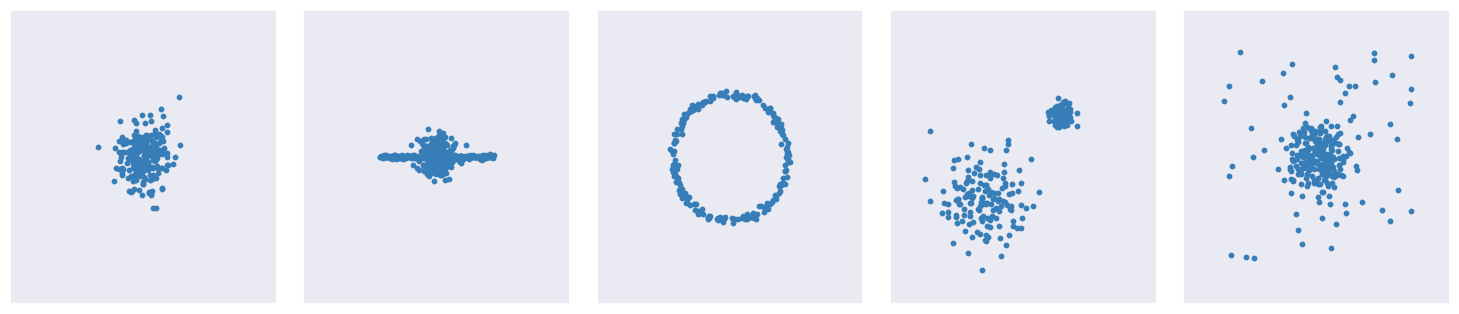

In [5]:
plot_datasets(addOutliers=False)

Ajout des valeurs aberrantes. Selon vous, quels ensembles seront les plus faciles à nettoyer? 

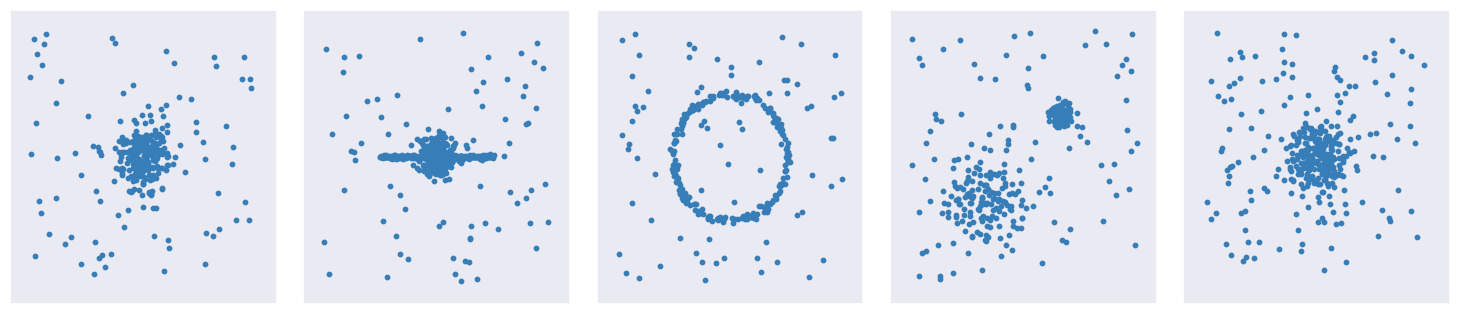

In [6]:
plot_datasets(addOutliers=True)

## Élimination des données aberrantes

À partir d'ici nous allons essayer différentes méthodes de détection de valeurs aberrantes.
Pour chacune des fonctions utilisées, n'hésitez pas à vous référer à la documentation
de [Scikit-learn](https://scikit-learn.org/stable/).

Généralement, une simple recherche sur Google de la fonction (par exemple ci-dessous, cherchez
« *EllipticEnvelope* » sur [Google](https://www.google.com/search?q=EllipticEnvelope)) vous mènera directement
à la bonne page de documentation.

La partie importante de cette documentation, qui n'est pas discutée dans ce module, est l'ensemble des
paramètres arbitrairement fixés à leurs valeurs par défaut que vous voudriez peut-être essayer de corriger
vu que vous connaissez déjà quelles sont les "bonnes" données et les "mauvaises" données. N'hésitez pas à expérimenter!

Dans les figures suivantes, les données identifiées comme correctes (*inliers*) sont affichées en orange. Les temps de calcul des différentes méthodes sont indiqués sous leur nom, dans le coin supérieur gauche.

### Covariance robuste

Cette méthode est basée sur l’hypothèse que les données normales suivent une distribution gaussienne multivariée.
Elle estime une matrice de covariance robuste (insensible aux points extrêmes) et identifie comme anomalies les points situés en dehors de l’ellipse de confiance.

Idéale lorsque les données forment un cluster globalement elliptique. Est-ce le cas ici?

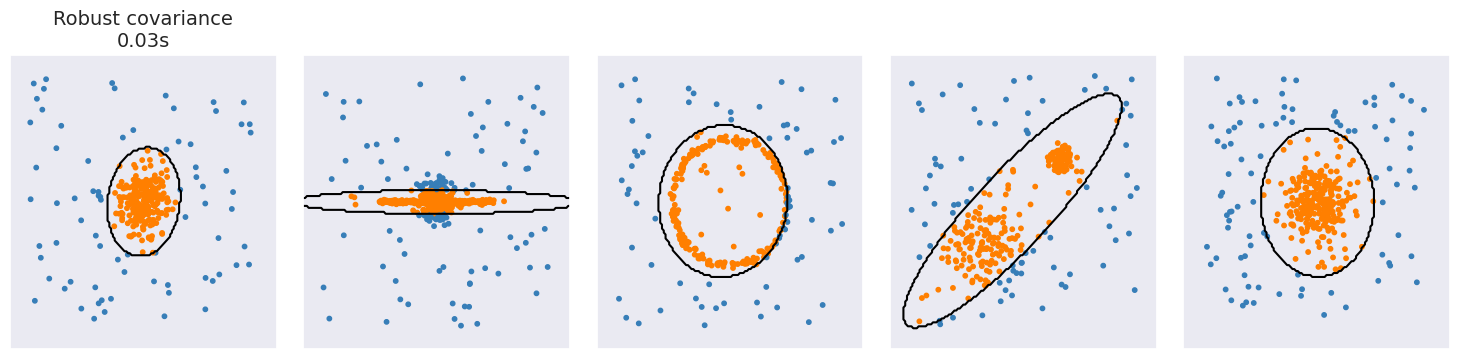

In [7]:
algo = ("Robust covariance", EllipticEnvelope(contamination=outliers_fraction))

plot_datasets(*algo)

L'hypothèse d'une seule ellipse de covariance basée sur les vraies données n'est pas très bonne ici, car les données, sauf dans le premier et le dernier panneau, ne ressemblent en rien à un nuage de points ellipsoïdal.

### SVM monoclasse

Cette méthode à frontière non linéaire apprend la surface la plus compacte entourant les données normales.
Tout point situé à l’extérieur de cette frontière est considéré comme une anomalie.

Très flexible, capable de capturer des formes complexes, mais sensible au choix des hyperparamètres.

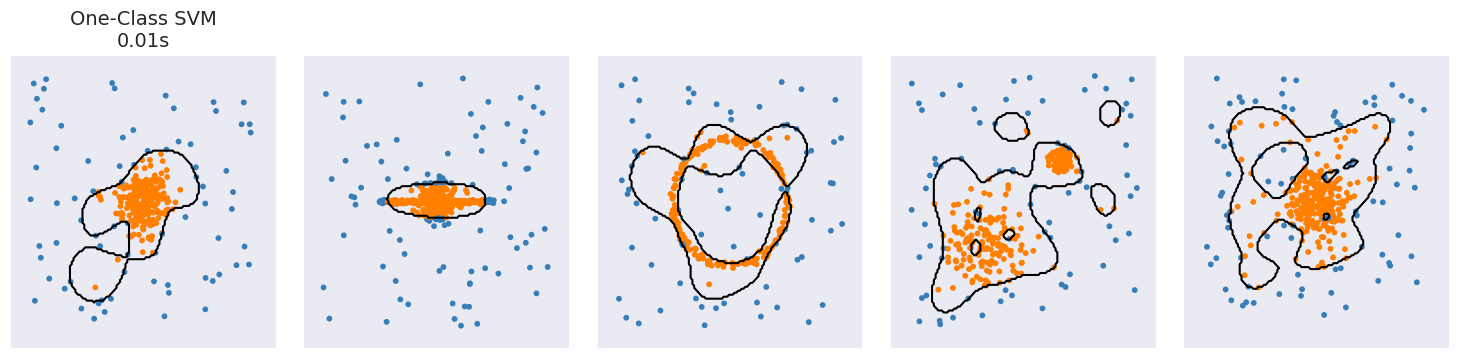

In [8]:
algo = ("One-Class SVM", svm.OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.2))

plot_datasets(*algo)

Notez que cette méthode rejette les points situés à l'intérieur de l'anneau dans le panneau du centre.

### Forêt d'isolation

Cette méthode est basée sur l’idée que les anomalies sont plus faciles à isoler que les points normaux.
Elle construit de nombreux arbres de décision aléatoires et mesure la profondeur moyenne nécessaire pour isoler chaque point.
Les points isolés rapidement sont marqués comme anomalies.

Rapide, scalable et efficace en haute dimension.

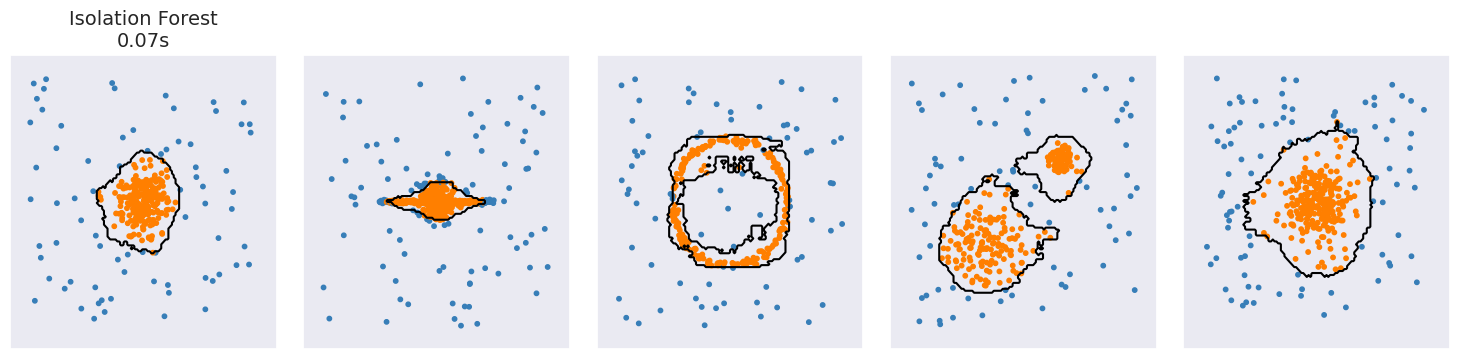

In [9]:
algo = (
    "Isolation Forest",
    IsolationForest(contamination=outliers_fraction, random_state=seed),
)

plot_datasets(*algo, show_scores=False)

Cette méthode fonctionne plutôt bien.

### Facteur d'aberration local

Cette méthode est fondée sur la densité locale : un point est considéré comme anormal s’il se trouve dans une région beaucoup moins dense que celle de ses voisins.

Très efficace pour détecter des anomalies locales dans des données non uniformes ou multi‑clusters.

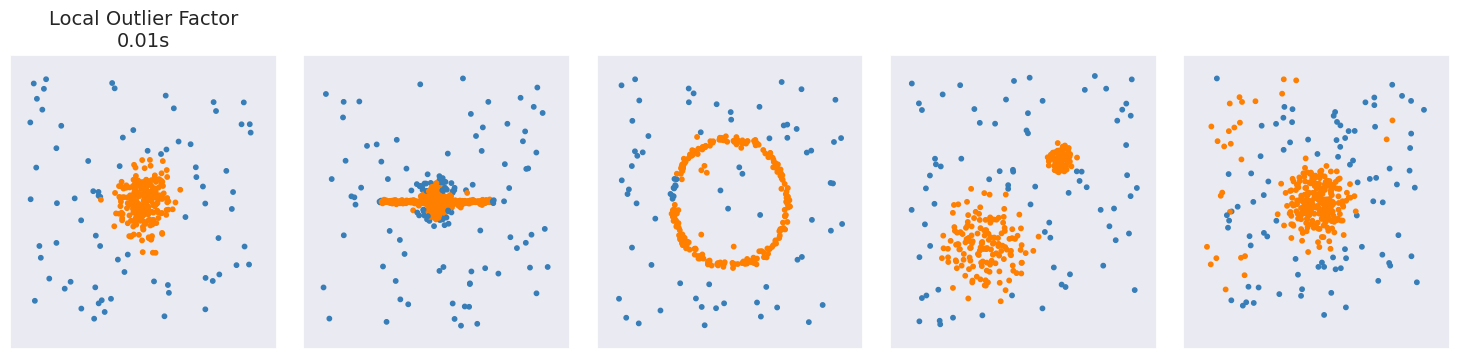

In [10]:
algo = (
    "Local Outlier Factor",
    LocalOutlierFactor(n_neighbors=35, contamination=outliers_fraction),
)

plot_datasets(*algo)

Cette méthode fonctionne également plutôt bien ; la plupart des valeurs aberrantes dans les quatre premiers panneaux sont identifiées. La distribution étendue des bonnes données dans le dernier panneau rend toutefois difficile l'identification des valeurs aberrantes, car en périphérie, la densité des bonnes et des mauvaises données est similaire.

## Conclusion

Les résultats de cette section montrent que l'identification des valeurs aberrantes n'est pas une opération triviale.
Les méthodes de la forêt d'isolation et du facteur d'aberration local performent le mieux avec les jeux de données utilisés ici. Il va donc falloir souvent tester plusieurs méthodes avec vos problèmes pour voir laquelle performe le mieux entre deux ou trois méthodes.